CODE TO SETUP ACCESS TO GITHUB FOR EVERY NEW COLAB SESSION RELATED TO THIS TASK

In [ ]:
from google.colab import userdata
import os

git_token = userdata.get('GIT_TOKEN')
git_username = "TalhaShoyo10"
repo_name = "CS-6304_PA0_28100131"
repo_url = f"https://{git_token}@github.com/{git_username}/{repo_name}.git"



if not os.path.exists(repo_name):
  !git clone {repo_url}
  print("Repo did not exist in local file system, cloned from github to initiate work on task.")
else:
  !git -C {repo_name} pull
  print("Repo already existed in local file system, pulled from github to catch up on any remote changes.")

Cloning into 'CS-6304_PA0_28100131'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 53 (delta 12), reused 10 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 71.78 KiB | 693.00 KiB/s, done.
Resolving deltas: 100% (12/12), done.
Repo did not exist in local file system, cloned from github to initiate work on task.


Imports and Setup


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# BASELINE SETUP


DATA PREPARATION AND LOADING

In [ ]:
#Applying the input size and normalisation transformations native to ImageNet on CIFAR-10 images
#As that is what the pretrained ResNet architecture is designed to work with
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

total_train_dataset = torchvision.datasets.CIFAR10(root = './data', train = True, download = True, transform = transform)
test_dataset = torchvision.datasets.CIFAR10(root = './data', train = False, download = True, transform=transform)

BATCH_SIZE = 64
VAL_SIZE = 5000
TRAIN_SIZE = len(total_train_dataset) - VAL_SIZE

# Verifying the 50,000 : 10,000 training to test data ratio for CIFAR-10
print(f"Number of Training examples: {len(total_train_dataset)}")
print(f"Number of Testing examples: {len(test_dataset)}")

# Verifying the classes are as documented for teh CIFAR-10 dataset
classes = total_train_dataset.classes
print(f"Classes: {classes}")

#Creating the practical train and validation datasets
train_dataset, val_dataset = torch.utils.data.random_split(total_train_dataset, [TRAIN_SIZE, VAL_SIZE],  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Number of Training batches: {len(train_loader)}")
print(f"Number of Validation batches: {len(val_loader)}")
print(f"Number of Testing batches: {len(test_loader)}")


100%|██████████| 170M/170M [09:47<00:00, 290kB/s]


Number of Training examples: 50000
Number of Testing examples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of Training batches: 704
Number of Validation batches: 79
Number of Testing batches: 157


Loading pretrained ResNet-152, Freezing BackBone, Setting up Trainable Classification Head

In [ ]:
#Loading pretrained ImageNet ResNet architecture
model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

#Freezing the Backbone
for para in model.parameters() :
  para.requires_grad = False

#Setting up the custom final classification layer
classes = 10
model.fc = nn.Linear(model.fc.in_features, classes)
model = model.to(device)

#Checking count of trainable parameters
trainable_paras = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_paras}")
#Checking count of all parameters to ensure trainable parameters are less than all parameters in count
total_para = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_para}")

Number of trainable parameters: 20490
Total number of parameters: 58164298


Train and Evaluate Functions

In [ ]:
def train(model, loader, criterion, optimizer, epoch_num, total_epochs):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for batch_index , (images, labels) in enumerate(loader):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    results = model(images)
    loss = criterion(results, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    predicted_values, predicted_indices = torch.max(results, 1)
    correct += (predicted_indices == labels).sum().item()
    total += labels.size(0)

    if batch_index % 100 == 0:
      print(f"Epoch {epoch_num+1}/{total_epochs}, Batch {batch_index}/{len(loader)}, Loss: {loss.item():.4f}")

  avg_train_loss = running_loss / total
  train_acc = correct / total
  return avg_train_loss, train_acc



def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            results = model(images)
            loss = criterion(results, labels)

            running_loss += loss.item() * images.size(0)
            predicted_values, predicted_indices = torch.max(results, 1)
            correct += (predicted_indices == labels).sum().item()
            total += labels.size(0)

    avg_eval_loss = running_loss / total
    eval_acc = correct / total
    return avg_eval_loss, eval_acc

Training Loop

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
EPOCHS = 5

history = {'train_loss': [], 'train_acc': [],'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, epoch, EPOCHS)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/5, Batch 0/704, Loss: 2.2952
Epoch 1/5, Batch 100/704, Loss: 1.0068
Epoch 1/5, Batch 200/704, Loss: 0.6624
Epoch 1/5, Batch 300/704, Loss: 0.5543
Epoch 1/5, Batch 400/704, Loss: 0.5457
Epoch 1/5, Batch 500/704, Loss: 0.6143
Epoch 1/5, Batch 600/704, Loss: 0.5103
Epoch 1/5, Batch 700/704, Loss: 0.6058
Epoch 1/5
Train Loss: 0.7207, Train Acc: 0.7802
Val Loss: 0.5143, Val Acc: 0.8266
Epoch 2/5, Batch 0/704, Loss: 0.5079
Epoch 2/5, Batch 100/704, Loss: 0.5407
Epoch 2/5, Batch 200/704, Loss: 0.4576
Epoch 2/5, Batch 300/704, Loss: 0.6265
Epoch 2/5, Batch 400/704, Loss: 0.6856
Epoch 2/5, Batch 500/704, Loss: 0.4195
Epoch 2/5, Batch 600/704, Loss: 0.3358
Epoch 2/5, Batch 700/704, Loss: 0.4844
Epoch 2/5
Train Loss: 0.5011, Train Acc: 0.8333
Val Loss: 0.4916, Val Acc: 0.8298
Epoch 3/5, Batch 0/704, Loss: 0.2145
Epoch 3/5, Batch 100/704, Loss: 0.4390
Epoch 3/5, Batch 200/704, Loss: 0.3980
Epoch 3/5, Batch 300/704, Loss: 0.3746
Epoch 3/5, Batch 400/704, Loss: 0.3918
Epoch 3/5, Batch 500/70

Loss and Accuracy Plots (For Training and Validation)

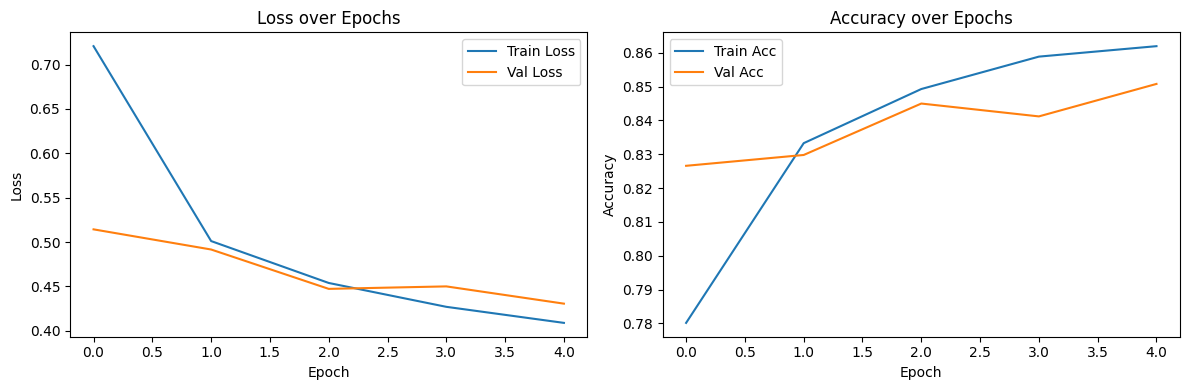

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.savefig('resnet152_baseline_training.png', dpi=150)
plt.show()

Test Dataset Evaluation

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.4493
Final Test Accuracy: 0.8488


Saving Results

In [ ]:
results = {
    'history': history,
    'final_train_acc': history['train_acc'][-1],
    'final_val_acc': history['val_acc'][-1],
    'final_test_acc': test_acc,
    'final_test_loss': test_loss,
    'num_epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam',
    'learning_rate': 0.001
}

with open('CS-6304_PA0_28100131/results/task1_resnet/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

torch.save(model.fc.state_dict(), 'CS-6304_PA0_28100131/results/task1_resnet/baseline_head_weights.pt')

print("Resuls Saved Successfully !!")

Resuls Saved Successfully !!


Githib Configuration

In [ ]:
!git config --global user.email "thebenbat5@gmail.com"
!git config --global user.name "TalhaShoyo10"

Commiting work to Github

In [ ]:
os.chdir('/content/CS-6304_PA0_28100131')

commit_message = "Task 1 - Comparing early layer gradinet signal of ResNet with skip connections and without skip connections, Checking training dynamics and validation acc of no skip connections model"
!git add -A
!git commit -m "{commit_message}"
!git push https://{git_token}@github.com/{git_username}/{repo_name}.git main

[main 1c5d7ea] Task 1: baseline frozen-backbone training complete, 5 epochs, Adam, test acc 84.88%
 1 file changed, 600 insertions(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 56.14 KiB | 9.36 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/TalhaShoyo10/CS-6304_PA0_28100131.git
   d887256..1c5d7ea  main -> main


# RESIDUAL CONNECTIONS IN PRACTICE

Modifying Bottleneck Block to exclude Skip Connection

In [ ]:
from torchvision.models.resnet import Bottleneck
#Identical to torchvison's bottlneck block structure, except for the skip connection (out += identity), which is removed from teh forward pass
class BottleneckNoSkip(Bottleneck):
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.relu(out)
        return out

Building the ablation(modified) model

In [ ]:
modified_model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

def no_skip_block(bottleneck_block):
  bottleneck_block.__class__ = BottleneckNoSkip
  return bottleneck_block

modified_model.layer1[0] = no_skip_block(modified_model.layer1[0])
modified_model.layer2[0] = no_skip_block(modified_model.layer2[0])
modified_model.layer4[0] = no_skip_block(modified_model.layer4[0])

print("Modified the first bottleneck blocks of Layers 1, 2 and 4 to remove their skip connections")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 179MB/s]


Modified the first bottleneck blocks of Layers 1, 2 and 4 to remove their skip connections


Gradient Diagnostic - Checking the ratio between early layer gradients of a model with all skip connections present and a model with some skip connections removed

In [ ]:
#Grabbing one batch to test with
batch_images, batch_labels = next(iter(train_loader))
batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

def early_layer_gradient(test_model, images, labels, criterion, model_title):
  for para in test_model.parameters():
    para.requires_grad = True

  test_model = test_model.to(device)
  test_model.train()

  for para in test_model.parameters():
    if para.grad is not None :
      para.grad = None

  results = test_model(images)
  loss = criterion(results, labels)
  loss.backward()

  early_layer_grad_norm = test_model.layer1[0].conv1.weight.grad.norm().item()

  print(f"Model : {model_title}")
  print(f"Early Layer Gradient Norm: {early_layer_grad_norm}")
  print("")

  for para in test_model.parameters():
    para.requires_grad = False

  return early_layer_grad_norm

intact_model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

no_skip_grad_norm = early_layer_gradient(modified_model, batch_images, batch_labels, criterion, "Modified Model(skip connections removed from first bottleneck blocks of layers 1, 2 and 4)")
skip_grad_norm = early_layer_gradient(intact_model, batch_images, batch_labels, criterion, "Base Model(skip connections still maintained for first bottleneck blocks of layers 1, 2 and 4)")

print (f"Early Layer Gradient Norm Ratio (Modified / Original) ---- {no_skip_grad_norm / skip_grad_norm :.4f}")

Comparing training dynamics and validation accuracy of modified model(some removed skip connections) with the baseline(no removed skip connections)

Preparing the modified model's trainable head

In [ ]:
for para in modified_model.parameters():
    para.requires_grad = False

num_classes = 10
modified_model.fc = nn.Linear(modified_model.fc.in_features, num_classes)
modified_model = modified_model.to(device)

modified_trainable_paras = sum(p.numel() for p in modified_model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {modified_trainable_paras}")

modified_total_paras = sum(p.numel() for p in modified_model.parameters())
print(f"Total number of parameters: {modified_total_paras}")

Training modified model's head

In [ ]:
criterion = nn.CrossEntropyLoss()
modified_optimizer = optim.Adam(modified_model.fc.parameters(), lr=0.001)
EPOCHS = 5

modified_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train(modified_model, train_loader, criterion, modified_optimizer, epoch, EPOCHS)
    val_loss, val_acc = evaluate(modified_model, val_loader, criterion)

    modified_history['train_loss'].append(train_loss)
    modified_history['train_acc'].append(train_acc)
    modified_history['val_loss'].append(val_loss)
    modified_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Loss and Accuracy curves for modified model (Training and Validation)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(modified_history['train_loss'], label='Train Loss')
axes[0].plot(modified_history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(modified_history['train_acc'], label='Train Acc')
axes[1].plot(modified_history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.savefig('resnet152_modified_training.png', dpi=150)
plt.show()

Test Dataset Evaluation (modified model)

In [ ]:
modified_test_loss, modified_test_acc = evaluate(modified_model, test_loader, criterion)
print(f"Final Test Loss: {modified_test_loss:.4f}")
print(f"Final Test Accuracy: {modified_test_acc:.4f}")

Saving results for modified model

In [ ]:
 modified_results = {
    'history': modified_history,
    'final_train_acc': modified_history['train_acc'][-1],
    'final_val_acc': modified_history['val_acc'][-1],
    'final_test_acc': modified_test_acc,
    'final_test_loss': modified_test_loss,
    'blocks_modified': ['layer1[0]', 'layer2[0]', 'layer4[0]'],
    'gradient_diagnostic': {
        'intact_grad_norm': skip_grad_norm,
        'modified_grad_norm': no_skip_grad_norm,
        'ratio': no_skip_grad_norm / skip_grad_norm
    },
    'num_epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam',
    'learning_rate': 0.001
}

with open('CS-6304_PA0_28100131/results/task1_resnet/modified_results.json', 'w') as f:
    json.dump(modified_results, f, indent=2)

torch.save(modified_model.fc.state_dict(), 'CS-6304_PA0_28100131/results/task1_resnet/modified_head_weights.pt')

print("modified results saved.")